# Weather Analysis (Observed vs Normal vs Records)

This notebook extends the existing analysis by comparing observed values against:

- Normal max/min/avg
- Record highs/lows for max/min (with years where available)

The focus is on PDF daily rows (`ingestion_type = 'pdf'`) for March 2026.

In [92]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Show full DataFrames in outputs (no head()/limits). The PDF slice below is ~10 March rows.
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

In [93]:
db_path = Path("../data/weather.db").resolve()
if not db_path.exists():
    raise FileNotFoundError(
        f"Database not found at {db_path}. From weather_project/, run poetry run ingest-weather (or python -m weather_project.ingest)."
    )

conn = sqlite3.connect(db_path)

query = """
SELECT
  d.observation_date,
  d.ingestion_type,
  d.temp_max_f,
  d.temp_min_f,
  d.temp_avg_f,
  d.daily_temp_max_obs,
  d.daily_temp_max_norm,
  d.daily_temp_max_record_high,
  d.daily_temp_max_record_high_year,
  d.daily_temp_max_record_low,
  d.daily_temp_max_record_low_year,
  d.daily_temp_min_obs,
  d.daily_temp_min_norm,
  d.daily_temp_min_record_high,
  d.daily_temp_min_record_high_year,
  d.daily_temp_min_record_low,
  d.daily_temp_min_record_low_year,
  d.daily_temp_avg_obs,
  d.daily_temp_avg_norm,
  d.daily_precip_inches_obs,
  d.daily_precip_inches_norm,
  d.daily_hdd_obs,
  d.daily_hdd_norm,
  d.daily_cdd_obs,
  d.daily_cdd_norm,
  d.quality_flag,
  d.ytd_precip_inches_obs,
  d.ytd_hdd_obs,
  d.ytd_cdd_obs,
  d.ytd_temp_avg_obs
FROM daily_weather d
WHERE d.ingestion_type = 'pdf'
ORDER BY d.observation_date
"""

df = pd.read_sql_query(query, conn)
df["observation_date"] = pd.to_datetime(df["observation_date"])
df

,observation_date,ingestion_type,temp_max_f,temp_min_f,temp_avg_f,daily_temp_max_obs,daily_temp_max_norm,daily_temp_max_record_high,daily_temp_max_record_high_year,daily_temp_max_record_low,daily_temp_max_record_low_year,daily_temp_min_obs,daily_temp_min_norm,daily_temp_min_record_high,daily_temp_min_record_high_year,daily_temp_min_record_low,daily_temp_min_record_low_year,daily_temp_avg_obs,daily_temp_avg_norm,daily_precip_inches_obs,daily_precip_inches_norm,daily_hdd_obs,daily_hdd_norm,daily_cdd_obs,daily_cdd_norm,quality_flag,ytd_precip_inches_obs,ytd_hdd_obs,ytd_cdd_obs,ytd_temp_avg_obs
0,2026-03-09,pdf,74.0,54.0,64.0,74.0,69.0,90.0,1934.0,54.0,1917.0,54.0,52.0,63.0,1916.0,31.0,1893.0,64.0,60.6,0.0,0.08,1.0,5.0,0.0,1.0,qc_0,NaN,NaN,NaN,NaN
1,2026-03-10,pdf,70.0,55.0,62.5,70.0,69.0,NaN,NaN,NaN,NaN,55.0,52.0,NaN,NaN,NaN,NaN,62.5,NaN,0.0,NaN,2.0,NaN,0.0,NaN,None,NaN,NaN,NaN,NaN
2,2026-03-11,pdf,76.0,51.0,63.5,76.0,70.0,93.0,1916.0,52.0,1922.0,51.0,52.0,67.0,1916.0,39.0,1917.0,63.5,60.8,0.0,0.09,NaN,NaN,NaN,NaN,qc_0,NaN,NaN,NaN,NaN
3,2026-03-12,pdf,92.0,56.0,74.0,92.0,70.0,93.0,2007.0,55.0,1912.0,56.0,52.0,59.0,2007.0,36.0,1893.0,74.0,60.9,0.0,0.08,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
4,2026-03-13,pdf,92.0,62.0,77.0,92.0,NaN,92.0,2026.0,52.0,1895.0,62.0,NaN,NaN,NaN,NaN,NaN,77.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
5,2026-03-14,pdf,83.0,56.0,69.5,83.0,70.0,93.0,2015.0,50.0,2025.0,56.0,52.0,62.0,2015.0,39.0,1895.0,69.5,61.0,0.0,0.08,NaN,NaN,5.0,1.0,None,NaN,NaN,NaN,NaN
6,2026-03-15,pdf,80.0,56.0,68.0,80.0,70.0,92.0,2015.0,53.0,1952.0,56.0,52.0,66.0,2015.0,37.0,1880.0,68.0,61.1,0.0,0.07,0.0,5.0,3.0,1.0,qc_0,6.72,NaN,130.0,NaN
7,2026-03-16,pdf,90.0,56.0,73.0,90.0,NaN,NaN,NaN,NaN,NaN,56.0,NaN,NaN,NaN,NaN,NaN,73.0,NaN,0.0,NaN,NaN,NaN,8.0,NaN,None,6.72,NaN,138.0,NaN
8,2026-03-17,pdf,98.0,64.0,81.0,98.0,70.0,98.0,2026.0,47.0,1945.0,64.0,53.0,66.0,1978.0,37.0,1881.0,81.0,61.3,NaN,NaN,NaN,NaN,16.0,1.0,None,NaN,NaN,NaN,NaN
9,2026-03-18,pdf,NaN,NaN,NaN,NaN,70.0,87.0,1997.0,56.0,1898.0,NaN,53.0,62.0,2015.0,38.0,1898.0,NaN,61.3,NaN,0.06,NaN,4.0,NaN,1.0,missing_marked,6.72,469.0,154.0,63.5


## CSV vs PDF Comparison (core metrics)

Each row is one **calendar day** that has **both** a CSV row and a PDF row (`ingestion_type`).

Columns are grouped in triples for easy scanning: `csv_*`, `pdf_*`, `delta_*` (delta = PDF minus CSV).

Set `compare_dates` to a list of strings like `["2026-03-14"]` to filter; leave empty `[]` for all overlap days.

The following code shows the **full** merge first, then (after a short markdown note) a **filtered** mismatch-only table — do not confuse the two.

In [94]:
query_both = """
SELECT
  d.observation_date,
  d.ingestion_type,
  d.temp_max_f,
  d.temp_min_f,
  d.temp_avg_f,
  d.precip_inches,
  d.hdd,
  d.cdd
FROM daily_weather d
WHERE d.ingestion_type IN ('csv', 'pdf')
ORDER BY d.observation_date, d.ingestion_type
"""

both = pd.read_sql_query(query_both, conn)
both["observation_date"] = pd.to_datetime(both["observation_date"])

both

,observation_date,ingestion_type,temp_max_f,temp_min_f,temp_avg_f,precip_inches,hdd,cdd
0,2026-01-01,csv,68.0,53.0,60.5,1.31,4.0,0.0
1,2026-01-02,csv,66.0,53.0,59.5,0.30,5.0,0.0
2,2026-01-03,csv,63.0,55.0,59.0,0.54,6.0,0.0
3,2026-01-04,csv,60.0,54.0,57.0,0.32,8.0,0.0
4,2026-01-05,csv,65.0,50.0,57.5,NaN,7.0,0.0
5,2026-01-06,csv,66.0,52.0,59.0,NaN,6.0,NaN
6,2026-01-07,csv,68.0,49.0,58.5,NaN,6.0,NaN
7,2026-01-08,csv,63.0,44.0,53.5,NaN,11.0,NaN
8,2026-01-09,csv,66.0,40.0,53.0,NaN,12.0,NaN
9,2026-01-10,csv,72.0,40.0,56.0,NaN,9.0,NaN


In [95]:
value_cols = ["temp_max_f", "temp_min_f", "temp_avg_f", "precip_inches", "hdd", "cdd"]

csv_side = both.loc[both["ingestion_type"] == "csv", ["observation_date", *value_cols]].rename(
    columns={c: f"csv_{c}" for c in value_cols}
)
pdf_side = both.loc[both["ingestion_type"] == "pdf", ["observation_date", *value_cols]].rename(
    columns={c: f"pdf_{c}" for c in value_cols}
)

# One row per day where BOTH CSV and PDF exist (March window for this dataset)
csv_vs_pdf = csv_side.merge(pdf_side, on="observation_date", how="inner")
for c in value_cols:
    csv_vs_pdf[f"delta_{c}"] = csv_vs_pdf[f"pdf_{c}"] - csv_vs_pdf[f"csv_{c}"]

# Readable column order: for each metric → csv, pdf, delta side by side
ordered = ["observation_date"]
for c in value_cols:
    ordered.extend([f"csv_{c}", f"pdf_{c}", f"delta_{c}"])
csv_vs_pdf = csv_vs_pdf[ordered].sort_values("observation_date").reset_index(drop=True)

# Optional: restrict to specific days, e.g. compare_dates = ["2026-03-14", "2026-03-15"]
compare_dates = []
if compare_dates:
    csv_vs_pdf = csv_vs_pdf[
        csv_vs_pdf["observation_date"].isin(pd.to_datetime(compare_dates))
    ].reset_index(drop=True)

csv_vs_pdf

,observation_date,csv_temp_max_f,pdf_temp_max_f,delta_temp_max_f,csv_temp_min_f,pdf_temp_min_f,delta_temp_min_f,csv_temp_avg_f,pdf_temp_avg_f,delta_temp_avg_f,csv_precip_inches,pdf_precip_inches,delta_precip_inches,csv_hdd,pdf_hdd,delta_hdd,csv_cdd,pdf_cdd,delta_cdd
0,2026-03-09,74.0,74.0,0.0,54.0,54.0,0.0,64.0,64.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,2026-03-10,70.0,70.0,0.0,55.0,55.0,0.0,62.5,62.5,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0
2,2026-03-11,76.0,76.0,0.0,51.0,51.0,0.0,63.5,63.5,0.0,0.0,0.0,0.0,1.0,NaN,NaN,0.0,NaN,NaN
3,2026-03-12,92.0,92.0,0.0,56.0,56.0,0.0,74.0,74.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,9.0,0.0
4,2026-03-13,92.0,92.0,0.0,62.0,62.0,0.0,77.0,77.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,12.0,36.0,24.0
5,2026-03-14,83.0,83.0,0.0,56.0,56.0,0.0,69.5,69.5,0.0,0.0,0.0,0.0,0.0,NaN,NaN,5.0,5.0,0.0
6,2026-03-15,80.0,80.0,0.0,56.0,56.0,0.0,68.0,68.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0,0.0
7,2026-03-16,90.0,90.0,0.0,56.0,56.0,0.0,73.0,73.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,8.0,8.0,0.0
8,2026-03-17,98.0,98.0,0.0,64.0,64.0,0.0,81.0,81.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,16.0,16.0,0.0
9,2026-03-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The **table in the cell above** is **`csv_vs_pdf`**: every calendar day that exists in **both** CSV and PDF, with `delta_* = pdf_* − csv_*`.

The **next code cell** prints **`csv_pdf_mismatches` only** — rows where any of the six core metrics differs beyond tolerance (temps/HDD/CDD: `|delta| > 1e-9`; precip: `> 0.05` in), **or** one source is null and the other is not (NaN delta). An **empty** frame means full agreement on those fields for all overlap days.

In [96]:
def _mismatch_mask(row):
    """True when CSV and PDF disagree on any legacy core metric (or one side is null)."""
    tol = 0.05
    metrics = [
        ("temp_max_f", 1e-9),
        ("temp_min_f", 1e-9),
        ("temp_avg_f", 1e-9),
        ("precip_inches", tol),
        ("hdd", 1e-9),
        ("cdd", 1e-9),
    ]
    for name, atol in metrics:
        d = row[f"delta_{name}"]
        cv = row[f"csv_{name}"]
        pv = row[f"pdf_{name}"]
        if pd.isna(cv) and pd.isna(pv):
            continue
        if pd.isna(d):
            return True
        if abs(float(d)) > atol:
            return True
    return False

if len(csv_vs_pdf):
    mask = csv_vs_pdf.apply(_mismatch_mask, axis=1)
    csv_pdf_mismatches = csv_vs_pdf.loc[mask].reset_index(drop=True)
else:
    csv_pdf_mismatches = csv_vs_pdf.copy()

csv_pdf_mismatches

,observation_date,csv_temp_max_f,pdf_temp_max_f,delta_temp_max_f,csv_temp_min_f,pdf_temp_min_f,delta_temp_min_f,csv_temp_avg_f,pdf_temp_avg_f,delta_temp_avg_f,csv_precip_inches,pdf_precip_inches,delta_precip_inches,csv_hdd,pdf_hdd,delta_hdd,csv_cdd,pdf_cdd,delta_cdd
0,2026-03-11,76.0,76.0,0.0,51.0,51.0,0.0,63.5,63.5,0.0,0.0,0.0,0.0,1.0,NaN,NaN,0.0,NaN,NaN
1,2026-03-13,92.0,92.0,0.0,62.0,62.0,0.0,77.0,77.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,12.0,36.0,24.0
2,2026-03-14,83.0,83.0,0.0,56.0,56.0,0.0,69.5,69.5,0.0,0.0,0.0,0.0,0.0,NaN,NaN,5.0,5.0,0.0
3,2026-03-16,90.0,90.0,0.0,56.0,56.0,0.0,73.0,73.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,8.0,8.0,0.0
4,2026-03-17,98.0,98.0,0.0,64.0,64.0,0.0,81.0,81.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,16.0,16.0,0.0


## PDF Parse vs Image-Verified Truth (Summary)

This table lists fields where the **parsed SQLite row** disagrees with values read from the
`data/raw/daily_images/march_*.png` screenshots (no OCR). For a full workflow (SQL, pitfalls,
and a copy-paste LLM prompt), see **`docs/llm_image_db_validation.md`** in this project.

Notes:
- `image_truth` lists only fields we expect in **`daily_*`** / selected **`ytd_*`** columns for this check.
- March 10 **record** temperatures appear in prose only; they are **not** compared here because the parser does not map them into `daily_*_record_*` yet.
- Empty output means the current parser + ingest match the chosen truth fields.

In [97]:
image_truth = [
    # Mar 09 table
    {"observation_date":"2026-03-09","daily_temp_max_norm":69.0,"daily_temp_max_record_high":90.0,"daily_temp_max_record_low":54.0,
     "daily_temp_min_norm":52.0,"daily_temp_min_record_high":63.0,"daily_temp_min_record_low":31.0,
     "daily_temp_avg_norm":60.6,"daily_precip_inches_norm":0.08,"daily_hdd_norm":5.0,"daily_cdd_norm":1.0},
    # Mar 10 prose + daily obs table
    {"observation_date":"2026-03-10","daily_temp_max_norm":69.0,"daily_temp_min_norm":52.0},
    # Mar 11 daily table
    {"observation_date":"2026-03-11","daily_temp_max_norm":70.0,"daily_temp_max_record_high":93.0,"daily_temp_max_record_low":52.0,
     "daily_temp_min_norm":52.0,"daily_temp_min_record_high":67.0,"daily_temp_min_record_low":39.0,
     "daily_temp_avg_norm":60.8,"daily_precip_inches_norm":0.09},
    # Mar 12 daily table
    {"observation_date":"2026-03-12","daily_temp_max_norm":70.0,"daily_temp_max_record_high":93.0,"daily_temp_max_record_low":55.0,
     "daily_temp_min_norm":52.0,"daily_temp_min_record_high":59.0,"daily_temp_min_record_low":36.0,
     "daily_temp_avg_norm":60.9,"daily_precip_inches_norm":0.08},
    # Mar 13 compact mixed layout
    {"observation_date":"2026-03-13","daily_temp_max_record_high":92.0,"daily_temp_max_record_low":52.0},
    # Mar 14 daily table
    {"observation_date":"2026-03-14","daily_temp_max_norm":70.0,"daily_temp_max_record_high":93.0,"daily_temp_max_record_low":50.0,
     "daily_temp_min_norm":52.0,"daily_temp_min_record_high":62.0,"daily_temp_min_record_low":39.0,
     "daily_temp_avg_norm":61.0,"daily_precip_inches_norm":0.08,"daily_cdd_norm":1.0},
    # Mar 15 daily table
    {"observation_date":"2026-03-15","daily_temp_max_norm":70.0,"daily_temp_max_record_high":92.0,"daily_temp_max_record_low":53.0,
     "daily_temp_min_norm":52.0,"daily_temp_min_record_high":66.0,"daily_temp_min_record_low":37.0,
     "daily_temp_avg_norm":61.1,"daily_precip_inches_norm":0.07,"daily_hdd_norm":5.0,"daily_cdd_norm":1.0},
    # Mar 16 daily values table has no daily norm/record columns shown
    {},
    # Mar 17 daily table
    {"observation_date":"2026-03-17","daily_temp_max_norm":70.0,"daily_temp_max_record_high":98.0,"daily_temp_max_record_low":47.0,
     "daily_temp_min_norm":53.0,"daily_temp_min_record_high":66.0,"daily_temp_min_record_low":37.0,
     "daily_temp_avg_norm":61.3,"daily_cdd_norm":1.0},
    # Mar 18 missing obs + norm + record extremes
    {"observation_date":"2026-03-18","daily_temp_max_norm":70.0,"daily_temp_max_record_high":87.0,"daily_temp_max_record_low":56.0,
     "daily_temp_min_norm":53.0,"daily_temp_min_record_high":62.0,"daily_temp_min_record_low":38.0,
     "daily_temp_avg_norm":61.3,"daily_precip_inches_norm":0.06,"daily_cdd_norm":1.0,
     "ytd_precip_inches_obs":6.72,"ytd_hdd_obs":469.0,"ytd_cdd_obs":154.0,"ytd_temp_avg_obs":63.5},
]

image_truth = [r for r in image_truth if r]
truth_df = pd.DataFrame(image_truth)
truth_df["observation_date"] = pd.to_datetime(truth_df["observation_date"])

In [98]:
pdf_df = df.copy()
compare_cols = [c for c in truth_df.columns if c != "observation_date"]
joined = truth_df.merge(pdf_df[["observation_date", *compare_cols]], on="observation_date", how="left", suffixes=("_true", "_parsed"))

rows = []
for _, row in joined.iterrows():
    dt = row["observation_date"].date().isoformat()
    for col in compare_cols:
        t = row.get(f"{col}_true")
        p = row.get(f"{col}_parsed")
        if pd.isna(t) and pd.isna(p):
            continue
        if pd.isna(t) and not pd.isna(p):
            continue
        if not pd.isna(t) and pd.isna(p):
            rows.append({"observation_date": dt, "field": col, "image_true": t, "parsed": None, "issue": "missing_in_parser"})
            continue
        if float(t) != float(p):
            rows.append({"observation_date": dt, "field": col, "image_true": t, "parsed": p, "issue": "value_mismatch"})

_gap_cols = ["observation_date", "field", "image_true", "parsed", "issue"]
parse_gap_summary = pd.DataFrame(rows, columns=_gap_cols)
if len(parse_gap_summary):
    parse_gap_summary = parse_gap_summary.sort_values(["observation_date", "field"]).reset_index(drop=True)
parse_gap_summary

,observation_date,field,image_true,parsed,issue


### Transition: validation → analysis

**Above this point**, the notebook is mostly **data-quality and reconciliation** work:

- Loading what landed in SQLite from CSV vs PDF (`ingestion_type`).
- Comparing sources on the same calendar day where both exist.
- Optionally comparing parsed PDF columns to a small hand-built “image truth” table (should be empty when the parser matches the screenshots for the fields we assert).

**From here onward**, we treat those checks as done and move into **exploratory analysis** on the PDF daily slice:

- We build a compact table of **observed** vs **normal** max/min/avg (and keep record high/low columns for context).
- We add **deltas** (`observed − normal`) for max, min, and average temperature.  
  Positive deltas mean warmer than the 1991–2020-style normal for that field; negative means cooler.  
  Rows with missing `*_obs` or `*_norm` will show as NaN in the deltas—that usually means the source layout didn’t expose that value, not necessarily a “bug” if validation already passed for core fields.

The plots in the following cells visualize the same ideas over time.

In [99]:
comparison = df[[
    "observation_date",
    "daily_temp_max_obs", "daily_temp_max_norm", "daily_temp_max_record_high", "daily_temp_max_record_low",
    "daily_temp_min_obs", "daily_temp_min_norm", "daily_temp_min_record_high", "daily_temp_min_record_low",
    "daily_temp_avg_obs", "daily_temp_avg_norm",
]].copy()

comparison["max_vs_norm_delta"] = comparison["daily_temp_max_obs"] - comparison["daily_temp_max_norm"]
comparison["min_vs_norm_delta"] = comparison["daily_temp_min_obs"] - comparison["daily_temp_min_norm"]
comparison["avg_vs_norm_delta"] = comparison["daily_temp_avg_obs"] - comparison["daily_temp_avg_norm"]

comparison

,observation_date,daily_temp_max_obs,daily_temp_max_norm,daily_temp_max_record_high,daily_temp_max_record_low,daily_temp_min_obs,daily_temp_min_norm,daily_temp_min_record_high,daily_temp_min_record_low,daily_temp_avg_obs,daily_temp_avg_norm,max_vs_norm_delta,min_vs_norm_delta,avg_vs_norm_delta
0,2026-03-09,74.0,69.0,90.0,54.0,54.0,52.0,63.0,31.0,64.0,60.6,5.0,2.0,3.4
1,2026-03-10,70.0,69.0,NaN,NaN,55.0,52.0,NaN,NaN,62.5,NaN,1.0,3.0,NaN
2,2026-03-11,76.0,70.0,93.0,52.0,51.0,52.0,67.0,39.0,63.5,60.8,6.0,-1.0,2.7
3,2026-03-12,92.0,70.0,93.0,55.0,56.0,52.0,59.0,36.0,74.0,60.9,22.0,4.0,13.1
4,2026-03-13,92.0,NaN,92.0,52.0,62.0,NaN,NaN,NaN,77.0,NaN,NaN,NaN,NaN
5,2026-03-14,83.0,70.0,93.0,50.0,56.0,52.0,62.0,39.0,69.5,61.0,13.0,4.0,8.5
6,2026-03-15,80.0,70.0,92.0,53.0,56.0,52.0,66.0,37.0,68.0,61.1,10.0,4.0,6.9
7,2026-03-16,90.0,NaN,NaN,NaN,56.0,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN
8,2026-03-17,98.0,70.0,98.0,47.0,64.0,53.0,66.0,37.0,81.0,61.3,28.0,11.0,19.7
9,2026-03-18,NaN,70.0,87.0,56.0,NaN,53.0,62.0,38.0,NaN,61.3,NaN,NaN,NaN


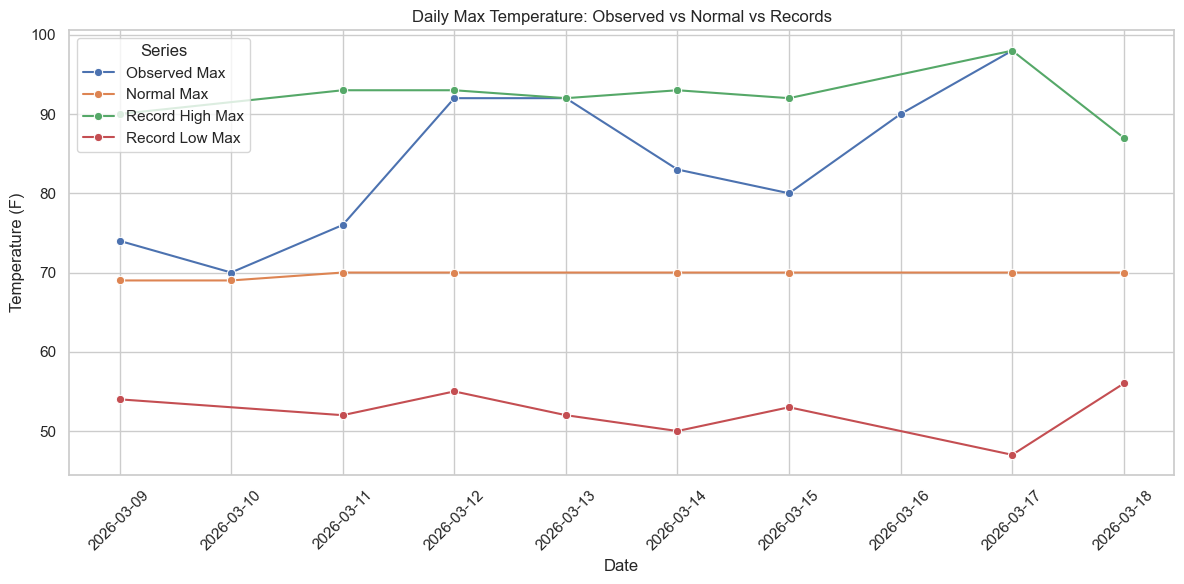

In [100]:
plot_df = df[["observation_date", "daily_temp_max_obs", "daily_temp_max_norm", "daily_temp_max_record_high", "daily_temp_max_record_low"]].copy()
plot_df = plot_df.rename(columns={
    "daily_temp_max_obs": "Observed Max",
    "daily_temp_max_norm": "Normal Max",
    "daily_temp_max_record_high": "Record High Max",
    "daily_temp_max_record_low": "Record Low Max",
})
plot_df = plot_df.melt(id_vars="observation_date", var_name="Series", value_name="TempF")

sns.lineplot(data=plot_df, x="observation_date", y="TempF", hue="Series", marker="o")
plt.title("Daily Max Temperature: Observed vs Normal vs Records")
plt.xlabel("Date")
plt.ylabel("Temperature (F)")
plt.xticks(rotation=45)
plt.tight_layout()

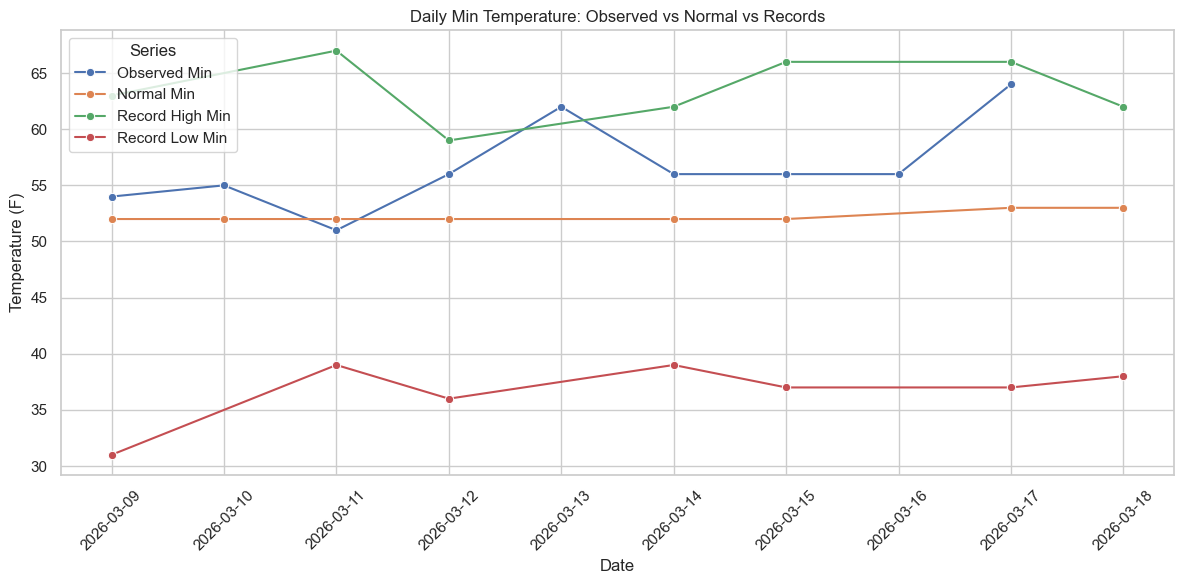

In [101]:
plot_df = df[["observation_date", "daily_temp_min_obs", "daily_temp_min_norm", "daily_temp_min_record_high", "daily_temp_min_record_low"]].copy()
plot_df = plot_df.rename(columns={
    "daily_temp_min_obs": "Observed Min",
    "daily_temp_min_norm": "Normal Min",
    "daily_temp_min_record_high": "Record High Min",
    "daily_temp_min_record_low": "Record Low Min",
})
plot_df = plot_df.melt(id_vars="observation_date", var_name="Series", value_name="TempF")

sns.lineplot(data=plot_df, x="observation_date", y="TempF", hue="Series", marker="o")
plt.title("Daily Min Temperature: Observed vs Normal vs Records")
plt.xlabel("Date")
plt.ylabel("Temperature (F)")
plt.xticks(rotation=45)
plt.tight_layout()

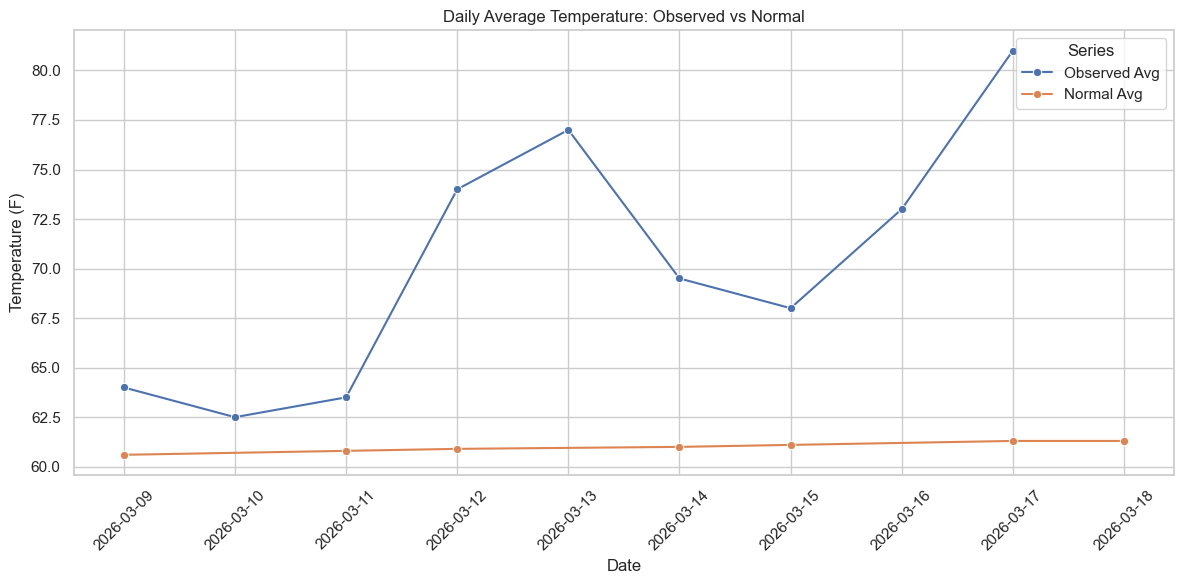

In [102]:
plot_df = df[["observation_date", "daily_temp_avg_obs", "daily_temp_avg_norm"]].copy()
plot_df = plot_df.rename(columns={
    "daily_temp_avg_obs": "Observed Avg",
    "daily_temp_avg_norm": "Normal Avg",
})
plot_df = plot_df.melt(id_vars="observation_date", var_name="Series", value_name="TempF")

sns.lineplot(data=plot_df, x="observation_date", y="TempF", hue="Series", marker="o")
plt.title("Daily Average Temperature: Observed vs Normal")
plt.xlabel("Date")
plt.ylabel("Temperature (F)")
plt.xticks(rotation=45)
plt.tight_layout()

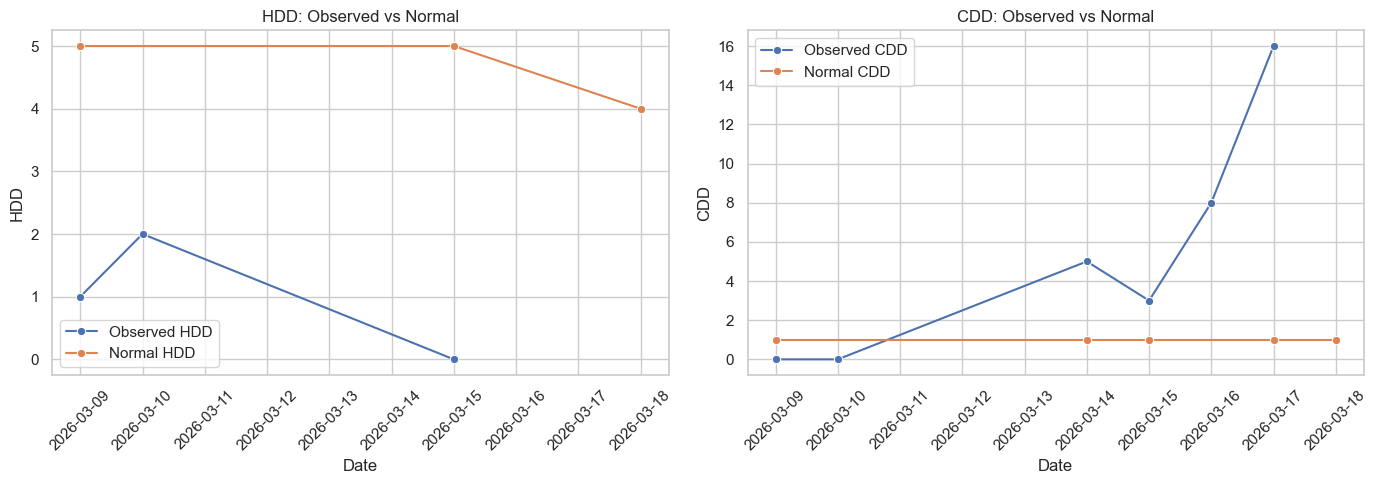

In [103]:
energy_df = df[["observation_date", "daily_hdd_obs", "daily_hdd_norm", "daily_cdd_obs", "daily_cdd_norm"]].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

sns.lineplot(data=energy_df, x="observation_date", y="daily_hdd_obs", marker="o", label="Observed HDD", ax=axes[0])
sns.lineplot(data=energy_df, x="observation_date", y="daily_hdd_norm", marker="o", label="Normal HDD", ax=axes[0])
axes[0].set_title("HDD: Observed vs Normal")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("HDD")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(data=energy_df, x="observation_date", y="daily_cdd_obs", marker="o", label="Observed CDD", ax=axes[1])
sns.lineplot(data=energy_df, x="observation_date", y="daily_cdd_norm", marker="o", label="Normal CDD", ax=axes[1])
axes[1].set_title("CDD: Observed vs Normal")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("CDD")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()

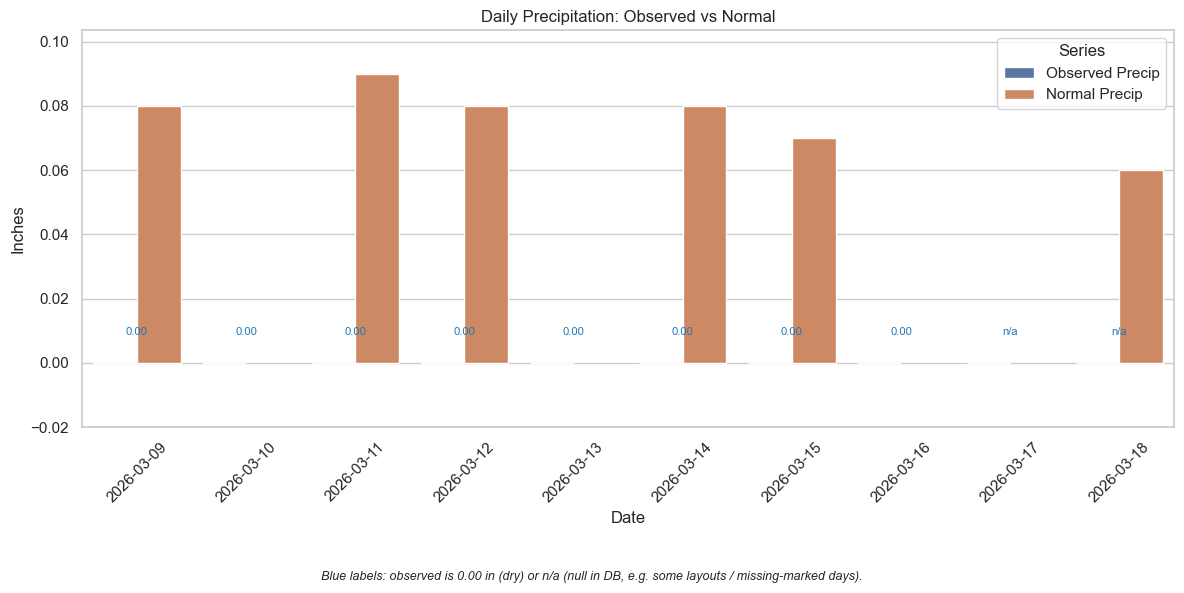

In [104]:
precip_df = df[["observation_date", "daily_precip_inches_obs", "daily_precip_inches_norm"]].copy()
precip_df = precip_df.rename(columns={
    "daily_precip_inches_obs": "Observed Precip",
    "daily_precip_inches_norm": "Normal Precip",
})

# Bars use filled values so dry days (0") and missing parsed obs still participate;
# tiny labels mark 0.00 / n/a where the blue bar would otherwise be invisible vs ~0.08" normals.
precip_plot = precip_df.copy()
precip_plot["Observed Precip"] = precip_plot["Observed Precip"].fillna(0.0)

precip_long = precip_plot.melt(id_vars="observation_date", var_name="Series", value_name="Inches")
ax = sns.barplot(data=precip_long, x="observation_date", y="Inches", hue="Series")
ymax = float(precip_long["Inches"].max()) if len(precip_long) else 0.1
ax.set_ylim(bottom=-0.02, top=max(ymax * 1.15, 0.05))

for i, (_, row) in enumerate(precip_df.reset_index(drop=True).iterrows()):
    raw = row["Observed Precip"]
    if pd.isna(raw):
        ax.text(i, 0.008, "n/a", ha="center", va="bottom", fontsize=8, color="#1f77b4")
    elif float(raw) == 0.0:
        ax.text(i, 0.008, "0.00", ha="center", va="bottom", fontsize=8, color="#1f77b4")

plt.title("Daily Precipitation: Observed vs Normal")
plt.xlabel("Date")
plt.ylabel("Inches")
plt.xticks(rotation=45)
plt.figtext(
    0.5,
    0.02,
    "Blue labels: observed is 0.00 in (dry) or n/a (null in DB, e.g. some layouts / missing-marked days).",
    ha="center",
    fontsize=9,
    style="italic",
)
plt.tight_layout(rect=(0, 0.08, 1, 1))

In [105]:
record_years = df[[
    "observation_date",
    "daily_temp_max_record_high_year",
    "daily_temp_max_record_low_year",
    "daily_temp_min_record_high_year",
    "daily_temp_min_record_low_year",
]].copy()

record_years

,observation_date,daily_temp_max_record_high_year,daily_temp_max_record_low_year,daily_temp_min_record_high_year,daily_temp_min_record_low_year
0,2026-03-09,1934.0,1917.0,1916.0,1893.0
1,2026-03-10,NaN,NaN,NaN,NaN
2,2026-03-11,1916.0,1922.0,1916.0,1917.0
3,2026-03-12,2007.0,1912.0,2007.0,1893.0
4,2026-03-13,2026.0,1895.0,NaN,NaN
5,2026-03-14,2015.0,2025.0,2015.0,1895.0
6,2026-03-15,2015.0,1952.0,2015.0,1880.0
7,2026-03-16,NaN,NaN,NaN,NaN
8,2026-03-17,2026.0,1945.0,1978.0,1881.0
9,2026-03-18,1997.0,1898.0,2015.0,1898.0
